# Vega risk through a local-volatility recalibration

This notebook builds a realistic dummy equity implied-volatility surface, creates a portfolio containing one ATM-forward call and one ATM-forward put at every monthly maturity from 1M to 12M, fits a Dupire local-volatility model, and reprices the portfolio with a Crank–Nicolson PDE. It then bumps the 6M ATM volatility quote, refits local volatility, and reports the resulting PV changes.

The bump is smooth and localized around the 6M ATM quote. Its value is exactly **+1 volatility point** at that quote; smoothing is necessary because the Dupire formula differentiates the surface in both strike and maturity.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from scipy.linalg import solve_banded
from scipy.stats import norm

pd.options.display.float_format = lambda x: f"{x:,.6f}"

# Dummy equity-market inputs
S0 = 100.0
r = 0.03       # continuously compounded risk-free rate
q = 0.01       # continuously compounded dividend yield
portfolio_maturities = np.arange(1, 13) / 12.0

# A dense grid is useful because Dupire needs stable first/second derivatives.
surface_maturities = np.r_[1 / 365, np.arange(1, 49) / 48.0]
log_moneyness_nodes = np.linspace(-0.55, 0.55, 111)

def dummy_implied_vol(k, T):
    """Smooth equity-like surface: downward skew, smile, and term structure."""
    k = np.asarray(k)
    T = np.asarray(T)
    return 0.19 - 0.11 * k + 0.12 * k**2 + 0.025 * np.sqrt(T)

def black_scholes_price(S, K, T, rate, dividend, vol, option_type):
    sqrt_T = np.sqrt(T)
    d1 = (np.log(S / K) + (rate - dividend + 0.5 * vol**2) * T) / (vol * sqrt_T)
    d2 = d1 - vol * sqrt_T
    if option_type == "call":
        return S * np.exp(-dividend * T) * norm.cdf(d1) - K * np.exp(-rate * T) * norm.cdf(d2)
    if option_type == "put":
        return K * np.exp(-rate * T) * norm.cdf(-d2) - S * np.exp(-dividend * T) * norm.cdf(-d1)
    raise ValueError("option_type must be 'call' or 'put'")

## 1. Dummy call/put portfolio priced from the implied-volatility surface

ATM means ATM-forward here, so each strike is $F(0,T)=S_0e^{(r-q)T}$. Each position has quantity one.

In [3]:
T_grid, k_grid = np.meshgrid(surface_maturities, log_moneyness_nodes, indexing="ij")
initial_iv_grid = dummy_implied_vol(k_grid, T_grid)

portfolio_rows = []
for T in portfolio_maturities:
    K_atm_forward = S0 * np.exp((r - q) * T)
    atm_vol = float(dummy_implied_vol(0.0, T))
    for option_type in ("call", "put"):
        portfolio_rows.append({
            "Option": option_type,
            "Strike": K_atm_forward,
            "MaturityYears": T,
            "Quantity": 1,
            "ImpliedVol": atm_vol,
            "BlackScholesPV": black_scholes_price(
                S0, K_atm_forward, T, r, q, atm_vol, option_type
            ),
        })

portfolio = pd.DataFrame(portfolio_rows)
portfolio

,Option,Strike,MaturityYears,Quantity,ImpliedVol,BlackScholesPV
0,call,100.166806,0.083333,1,0.197217,2.269044
1,put,100.166806,0.083333,1,0.197217,2.269044
2,call,100.333890,0.166667,1,0.200206,3.254373
3,put,100.333890,0.166667,1,0.200206,3.254373
4,call,100.501252,0.250000,1,0.202500,4.027485
5,put,100.501252,0.250000,1,0.202500,4.027485
6,call,100.668894,0.333333,1,0.204434,4.690319
7,put,100.668894,0.333333,1,0.204434,4.690319
8,call,100.836815,0.416667,1,0.206137,5.282402
9,put,100.836815,0.416667,1,0.206137,5.282402


## 2. Fit local volatility with Dupire

The implied vols are first converted to call prices on a fixed strike grid. A bicubic spline provides $C_T$, $C_K$, and $C_{KK}$, and Dupire gives

$$\sigma_{loc}^2(K,T)=\frac{C_T+(r-q)K C_K+qC}{\tfrac12K^2C_{KK}}.$$

Local volatility is held flat outside the liquid strike interval [70, 145], a conventional stable tail extrapolation.

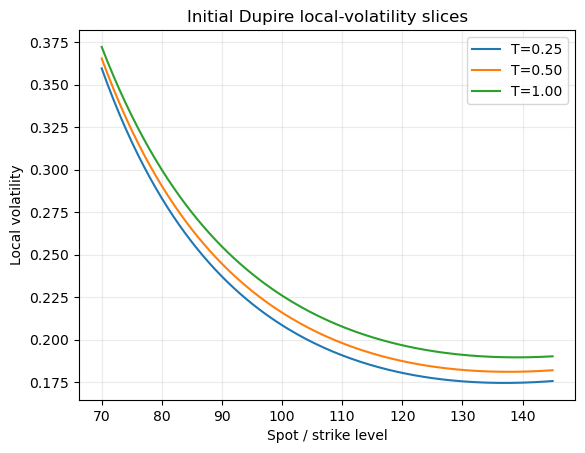

In [4]:
def fit_dupire_local_vol(iv_grid):
    """Fit C(T,K), then return sigma_local(S,t) from Dupire derivatives."""
    iv_spline = RectBivariateSpline(
        surface_maturities, log_moneyness_nodes, iv_grid, kx=3, ky=3, s=0
    )

    absolute_strikes = np.linspace(55.0, 165.0, 441)
    call_rows = []
    for T in surface_maturities:
        forward = S0 * np.exp((r - q) * T)
        k = np.log(absolute_strikes / forward)
        vols = iv_spline.ev(np.full_like(absolute_strikes, T), k)
        call_rows.append(
            black_scholes_price(S0, absolute_strikes, T, r, q, vols, "call")
        )

    call_spline = RectBivariateSpline(
        surface_maturities, absolute_strikes, np.asarray(call_rows),
        kx=3, ky=3, s=0
    )

    def local_vol(S, t):
        # Flat time/strike extrapolation keeps the PDE stable outside quotes.
        t_eval = np.clip(np.asarray(t), surface_maturities[0], surface_maturities[-1])
        S_eval = np.clip(np.asarray(S), 70.0, 145.0)
        tt, ss = np.broadcast_arrays(t_eval, S_eval)
        flat_t, flat_s = tt.ravel(), ss.ravel()

        C = call_spline.ev(flat_t, flat_s).reshape(tt.shape)
        C_T = call_spline.ev(flat_t, flat_s, dx=1, dy=0).reshape(tt.shape)
        C_K = call_spline.ev(flat_t, flat_s, dx=0, dy=1).reshape(tt.shape)
        C_KK = call_spline.ev(flat_t, flat_s, dx=0, dy=2).reshape(tt.shape)

        numerator = C_T + (r - q) * ss * C_K + q * C
        denominator = 0.5 * ss**2 * C_KK
        local_variance = np.divide(
            numerator, denominator, out=np.full_like(numerator, np.nan),
            where=denominator > 1e-12,
        )
        local_variance = np.nan_to_num(
            local_variance, nan=0.04, posinf=2.25, neginf=0.0025
        )
        return np.sqrt(np.clip(local_variance, 0.0025, 2.25))

    return local_vol

initial_local_vol = fit_dupire_local_vol(initial_iv_grid)

# Quick look at the initial local-vol slices.
spot_levels = np.linspace(70, 145, 151)
for T in (0.25, 0.50, 1.00):
    plt.plot(spot_levels, initial_local_vol(spot_levels, T), label=f"T={T:.2f}")
plt.xlabel("Spot / strike level")
plt.ylabel("Local volatility")
plt.title("Initial Dupire local-volatility slices")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 3. Crank–Nicolson PDE pricer

This solves $V_t+\tfrac12\sigma_{loc}^2(S,t)S^2V_{SS}+(r-q)SV_S-rV=0$ backward from the option payoff.

In [5]:
def local_vol_pde_price(K, T, option_type, local_vol, n_space=601, steps_per_year=900):
    """European option PV from a Crank–Nicolson local-vol PDE."""
    S_max = 4.0 * S0
    S = np.linspace(0.0, S_max, n_space)
    dS = S[1] - S[0]
    V = np.maximum(S - K, 0.0) if option_type == "call" else np.maximum(K - S, 0.0)

    n_time = max(80, int(np.ceil(steps_per_year * T)))
    dt = T / n_time
    S_inner = S[1:-1]
    n_inner = len(S_inner)

    def boundary_values(calendar_time):
        tau = T - calendar_time
        if option_type == "call":
            return 0.0, S_max * np.exp(-q * tau) - K * np.exp(-r * tau)
        return K * np.exp(-r * tau), 0.0

    for step in range(n_time):
        t_old = T - step * dt
        t_new = t_old - dt
        t_mid = 0.5 * (t_old + t_new)
        sigma = local_vol(S_inner, t_mid)

        a = 0.5 * sigma**2 * S_inner**2 / dS**2 - (r - q) * S_inner / (2.0 * dS)
        b = -sigma**2 * S_inner**2 / dS**2 - r
        c = 0.5 * sigma**2 * S_inner**2 / dS**2 + (r - q) * S_inner / (2.0 * dS)

        rhs = (1.0 + 0.5 * dt * b) * V[1:-1]
        rhs += 0.5 * dt * (a * V[:-2] + c * V[2:])

        low_new, high_new = boundary_values(t_new)
        rhs[0] += 0.5 * dt * a[0] * low_new
        rhs[-1] += 0.5 * dt * c[-1] * high_new

        # Banded representation of the tridiagonal left-hand-side matrix.
        matrix = np.zeros((3, n_inner))
        matrix[0, 1:] = -0.5 * dt * c[:-1]
        matrix[1, :] = 1.0 - 0.5 * dt * b
        matrix[2, :-1] = -0.5 * dt * a[1:]

        V[0], V[-1] = low_new, high_new
        V[1:-1] = solve_banded((1, 1), matrix, rhs)

    return float(np.interp(S0, S, V))

portfolio["PVLocalVolInitial"] = [
    local_vol_pde_price(row.Strike, row.MaturityYears, row.Option, initial_local_vol)
    for row in portfolio.itertuples(index=False)
]

fit_check = portfolio[["Option", "Strike", "MaturityYears", "BlackScholesPV", "PVLocalVolInitial"]].copy()
fit_check["FitError"] = fit_check["PVLocalVolInitial"] - fit_check["BlackScholesPV"]
print(f"Maximum absolute initial repricing error: {fit_check['FitError'].abs().max():.6f}")
fit_check

Maximum absolute initial repricing error: 0.009696


,Option,Strike,MaturityYears,BlackScholesPV,PVLocalVolInitial,FitError
0,call,100.166806,0.083333,2.269044,2.259348,-0.009696
1,put,100.166806,0.083333,2.269044,2.259348,-0.009696
2,call,100.333890,0.166667,3.254373,3.248476,-0.005897
3,put,100.333890,0.166667,3.254373,3.248476,-0.005897
4,call,100.501252,0.250000,4.027485,4.022207,-0.005277
5,put,100.501252,0.250000,4.027485,4.022207,-0.005277
6,call,100.668894,0.333333,4.690319,4.684427,-0.005892
7,put,100.668894,0.333333,4.690319,4.684427,-0.005892
8,call,100.836815,0.416667,5.282402,5.278418,-0.003984
9,put,100.836815,0.416667,5.282402,5.278418,-0.003984


## 4. Bump 6M ATM implied volatility and refit local volatility

A Gaussian bump is centered at $(k,T)=(0,0.5)$, with a peak of 0.01. It represents a one-vol-point shock to the 6M ATM quote while preserving a differentiable surface for Dupire calibration.

Initial 6M ATM vol: 20.7678%
Bumped  6M ATM vol: 21.7678%
Bump applied:       1.0000%


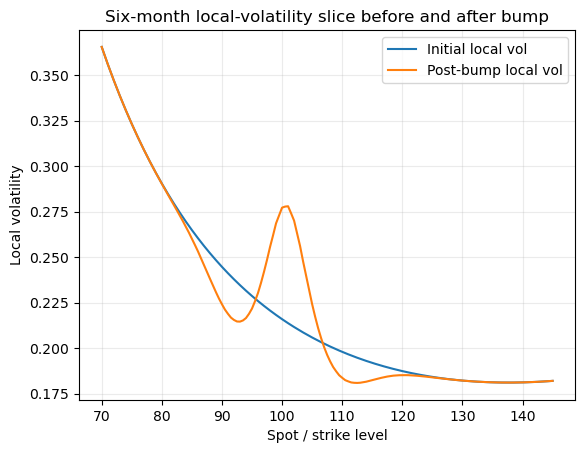

In [6]:
bump_size = 0.01            # +1 volatility point
bump_maturity = 0.50        # 6 months
maturity_width = 1.5 / 12.0
moneyness_width = 0.055

smooth_bump = bump_size * np.exp(
    -0.5 * ((T_grid - bump_maturity) / maturity_width) ** 2
    -0.5 * (k_grid / moneyness_width) ** 2
)
bumped_iv_grid = initial_iv_grid + smooth_bump
bumped_local_vol = fit_dupire_local_vol(bumped_iv_grid)

six_month_row = np.argmin(np.abs(surface_maturities - bump_maturity))
atm_col = np.argmin(np.abs(log_moneyness_nodes))
print(f"Initial 6M ATM vol: {initial_iv_grid[six_month_row, atm_col]:.4%}")
print(f"Bumped  6M ATM vol: {bumped_iv_grid[six_month_row, atm_col]:.4%}")
print(f"Bump applied:       {smooth_bump[six_month_row, atm_col]:.4%}")

plt.plot(spot_levels, initial_local_vol(spot_levels, 0.50), label="Initial local vol")
plt.plot(spot_levels, bumped_local_vol(spot_levels, 0.50), label="Post-bump local vol")
plt.xlabel("Spot / strike level")
plt.ylabel("Local volatility")
plt.title("Six-month local-volatility slice before and after bump")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 5. Interactive 3D local-volatility surfaces

The two Plotly surfaces use identical spot, maturity, height, and color scales, making the effect of the 6M ATM volatility bump directly comparable. Hover over either surface to inspect individual values.

In [7]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Focus on the liquid equity region and the portfolio's 1M-12M horizon.
surface_spots = np.linspace(75.0, 135.0, 81)
surface_times = np.linspace(1 / 12, 1.0, 61)
spot_mesh, time_mesh = np.meshgrid(surface_spots, surface_times)

initial_lv_surface = initial_local_vol(spot_mesh, time_mesh)
bumped_lv_surface = bumped_local_vol(spot_mesh, time_mesh)
shared_min = min(initial_lv_surface.min(), bumped_lv_surface.min())
shared_max = max(initial_lv_surface.max(), bumped_lv_surface.max())

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "surface"}, {"type": "surface"}]],
    subplot_titles=("Initial local volatility", "Local volatility after 6M ATM bump"),
)

surface_style = dict(
    x=spot_mesh, y=time_mesh, colorscale="Viridis",
    cmin=shared_min, cmax=shared_max,
    hovertemplate="Spot=%{x:.2f}<br>Maturity=%{y:.3f}y<br>Local vol=%{z:.2%}<extra></extra>",
)
fig.add_trace(
    go.Surface(z=initial_lv_surface, showscale=False, **surface_style),
    row=1, col=1,
)
fig.add_trace(
    go.Surface(
        z=bumped_lv_surface, showscale=True,
        colorbar=dict(title="Local vol", tickformat=".1%", len=0.75),
        **surface_style,
    ),
    row=1, col=2,
)

axis_style = dict(
    xaxis_title="Spot / strike level",
    yaxis_title="Maturity (years)",
    zaxis_title="Local volatility",
    zaxis_tickformat=".1%",
    zaxis_range=[shared_min, shared_max],
)
fig.update_layout(
    title="Dupire local-volatility surface: before vs. after bump",
    scene=axis_style, scene2=axis_style,
    width=1250, height=620, margin=dict(l=10, r=80, b=10, t=90),
)
fig.show()

In [8]:
test

NameError: name 'test' is not defined

## 6. Reprice the portfolio and summarize the vega scenario

`Option` is used as the row index so the output has exactly the five requested data columns.

In [ ]:
portfolio["PVLocalVolPostBump"] = [
    local_vol_pde_price(row.Strike, row.MaturityYears, row.Option, bumped_local_vol)
    for row in portfolio.itertuples(index=False)
]
portfolio["PVDifference"] = portfolio["PVLocalVolPostBump"] - portfolio["PVLocalVolInitial"]

summary = portfolio[[
    "Option", "Strike", "MaturityYears",
    "PVLocalVolInitial", "PVLocalVolPostBump", "PVDifference"
]].set_index("Option")

summary.columns = [
    "Option Strike", "Option Maturity (years)",
    "PV under local vol initial", "PV under local vol fitted post bump",
    "Difference",
]
summary

,Option Strike,Option Maturity (years),PV under local vol initial,PV under local vol fitted post bump,Difference
Option,,,,,
call,100.166806,0.083333,2.259348,2.259795,0.000447
put,100.166806,0.083333,2.259348,2.259795,0.000447
call,100.333890,0.166667,3.248476,3.253122,0.004646
put,100.333890,0.166667,3.248476,3.253122,0.004646
call,100.501252,0.250000,4.022207,4.049126,0.026918
put,100.501252,0.250000,4.022207,4.049126,0.026918
call,100.668894,0.333333,4.684427,4.778844,0.094417
put,100.668894,0.333333,4.684427,4.778844,0.094417
call,100.836815,0.416667,5.278418,5.483406,0.204988
